## DetoxiGuard: An Agentic LLM System for Toxic Comment Detection and Correction

This notebook is for the **EDA**.   
Tasks and distribution of work:   
1. Label combination distribution: Yanfu Wang
2. Label co-occurrence count heatmap: Yanfu Wang
3. Multi-label correlation matrix heatmap (Pearson): Ruide Yin
4. Word cloud segmentation (uni/bi/tri-gram per label): Ruide Yin
5. High-frequency words for each label: Ruide Yin
6. Per-label length distribution: Langyue Zhao
7. Toxic vs non-toxic length boxplot: Yanfu Wang
8. Baseline difficulty preview via logistic regression: Langyue Zhao

### Content Disclaimer    
The visualizations below (word clouds and word charts) are generated directly from the *Jigsaw Toxic Comment Classification dataset* sourced from Wikipedia comment history. As a result, they may contain **highly offensive, explicit, and disturbing language**, including but not limited to:
- Racial slurs and ethnically targeted hate speech and insult    
- Homophobic and transphobic language   
- Sexually explicit terms   
- Severe profanity and personal insults

These words are displayed **solely for the purpose of exploratory data analysis (EDA)**, in order to examine linguistic patterns and vocabulary distributions across toxicity categories. Their appearance in this analysis does **not constitute endorsement or promotion** of such language. Instead, examining these patterns is a necessary step in the future development of system that can **detect and correct toxic or harmful language**.

### Commitment to Anti-Racism, Inclusion, and Equity
As NYU students, we value an inclusive and equitable environment for everyone engaging with this work. We are committed to fostering a sense of community in this project where individuals of all backgrounds, beliefs, ethnicities, national origins, gender identities, sexual orientations, religious and political affiliations, and abilities are treated with respect. It is our intent that the diverse perspectives we bring to this project be viewed as a resource, a strength, and a benefit — and that this work contribute meaningfully toward a safer and more equitable digital environment for all.

This content is intended for **academic use only**, and is shared in the spirit of building technology that actively works against hate and toxicity.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_theme(style="whitegrid", palette="husl")
LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
LABEL_COLORS = sns.color_palette("husl", len(LABELS))

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, fbeta_score, recall_score
from sklearn.multiclass import OneVsRestClassifier

**0. Data Preprocess and Trivial EDA**

In [2]:
def preprocess(text):
    """Full preprocessing pipeline: clean → tokenize → lemmatize."""
    text = cleanTexts(text)
    tokens = tokenizeTexts(text)
    return ' '.join(lemmaTexts(tokens))

def cleanTexts(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenizeTexts(text):
    stop_words = set(stopwords.words('english'))
    return [w for w in word_tokenize(text) if w not in stop_words]

def lemmaTexts(tokens):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(w) for w in tokens]

train_df = pd.read_csv('../data/train_split.csv')
test_df  = pd.read_csv('../data/test_split.csv')
train_df['comment_text'] = train_df['comment_text'].apply(preprocess)
test_df['comment_text']  = test_df['comment_text'].apply(preprocess)
print("Preprocessing done. Shape:", train_df.shape)

Preprocessing done. Shape: (178839, 8)


Label Counts

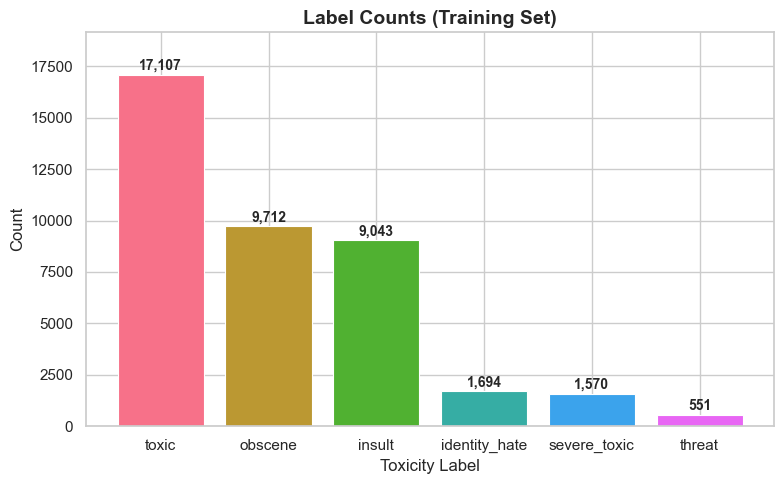

In [3]:
x = train_df[LABELS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x.index, x.values, color=LABEL_COLORS, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, x.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Label Counts (Training Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Toxicity Label', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, x.max() * 1.12)
plt.tight_layout()
plt.show()

Labels per comment

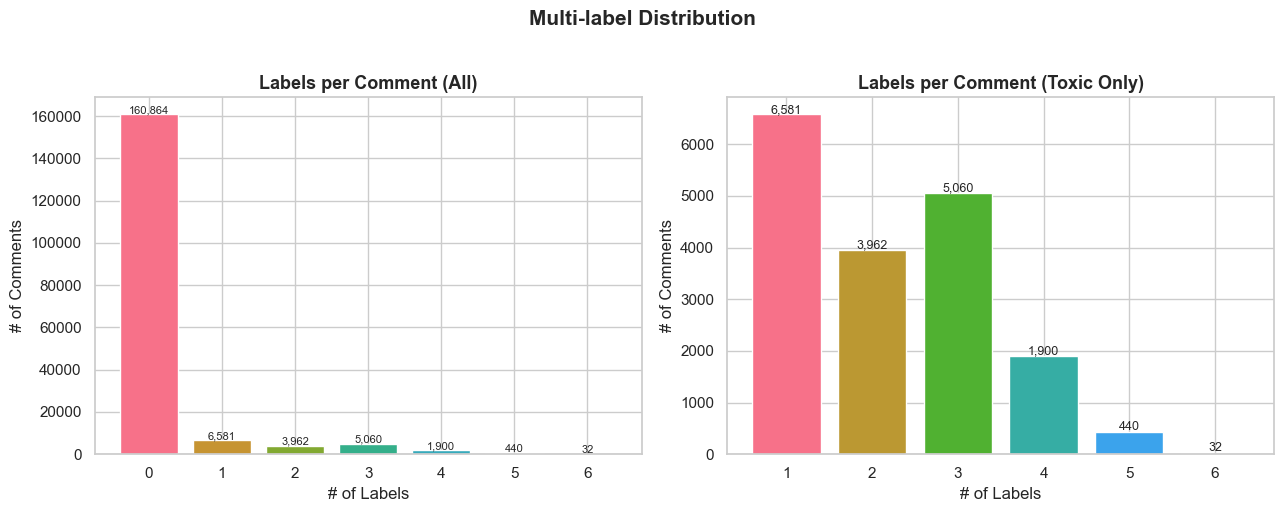

In [4]:
rowsums = train_df[LABELS].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: all comments (including 0-label)
cnt_all = rowsums.value_counts().sort_index()
axes[0].bar(cnt_all.index, cnt_all.values,
            color=sns.color_palette("husl", len(cnt_all)), edgecolor='white')
axes[0].set_title('Labels per Comment (All)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('# of Labels')
axes[0].set_ylabel('# of Comments')
for i, (idx, v) in enumerate(cnt_all.items()):
    axes[0].text(idx, v + 500, f'{v:,}', ha='center', fontsize=8)

# Right: toxic-only comments
cnt_toxic = rowsums[rowsums > 0].value_counts().sort_index()
axes[1].bar(cnt_toxic.index, cnt_toxic.values,
            color=sns.color_palette("husl", len(cnt_toxic)), edgecolor='white')
axes[1].set_title('Labels per Comment (Toxic Only)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('# of Labels')
axes[1].set_ylabel('# of Comments')
for idx, v in cnt_toxic.items():
    axes[1].text(idx, v + 30, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Multi-label Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**1. Label Combination Distribution**

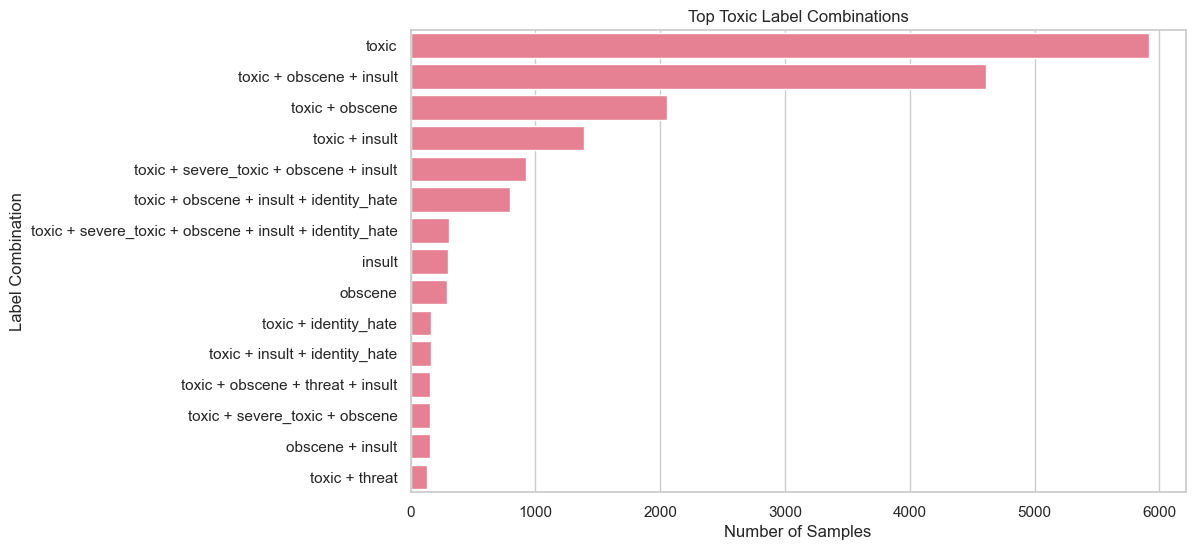

In [5]:
# create readable label combination names
def combo_to_labels(row):
    labels = [label for label in LABELS if row[label] == 1]
    return " + ".join(labels) if labels else "non-toxic"

train_df["label_combo_name"] = train_df.apply(combo_to_labels, axis=1)

# remove non-toxic
toxic_df = train_df[train_df["label_combo_name"] != "non-toxic"]

# count combinations
combo_counts = toxic_df["label_combo_name"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=combo_counts.values, y=combo_counts.index)

plt.title("Top Toxic Label Combinations")
plt.xlabel("Number of Samples")
plt.ylabel("Label Combination")

plt.show()

**2. Label Co-occurence Count Heatmap**

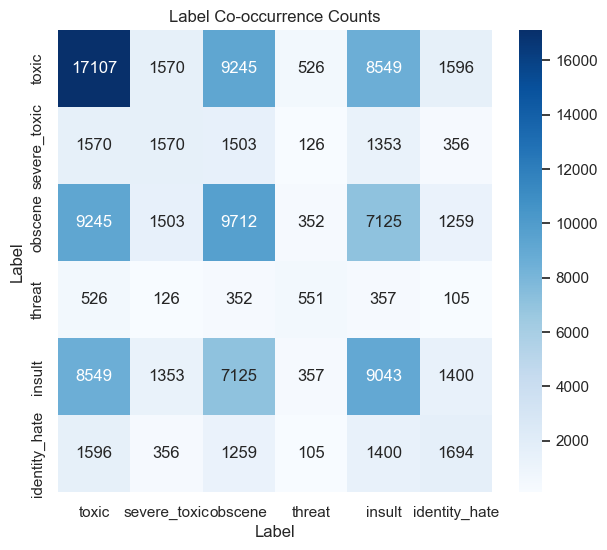

In [6]:
co_mat = np.zeros((len(LABELS), len(LABELS)), dtype=int)

for i, a in enumerate(LABELS):
    for j, b in enumerate(LABELS):
        co_mat[i, j] = int(((train_df[a] == 1) & (train_df[b] == 1)).sum())

co_df = pd.DataFrame(co_mat, index=LABELS, columns=LABELS)

plt.figure(figsize=(7, 6))
sns.heatmap(co_df, annot=True, fmt="d", cmap="Blues")
plt.title("Label Co-occurrence Counts")
plt.xlabel("Label")
plt.ylabel("Label")
plt.show()

**3. Multi-label Pearson Correlation Heatmap**

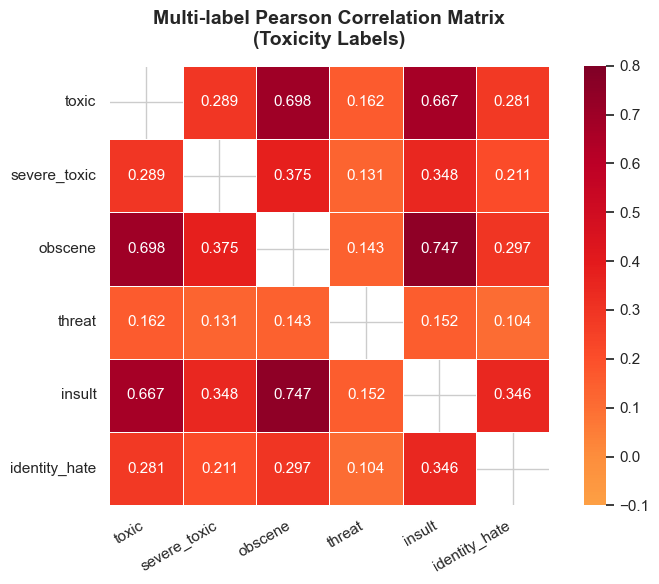


Strongest correlations (excluding self):
      Label A       Label B        r
      obscene        insult 0.747053
      obscene         toxic 0.697639
       insult         toxic 0.666720
      obscene  severe_toxic 0.375000
 severe_toxic        insult 0.348428
       insult identity_hate 0.346282
identity_hate       obscene 0.297272
        toxic  severe_toxic 0.289364


In [7]:
corr_matrix = train_df[LABELS].corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)  # hide diagonal (self-correlation = 1)

heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    center=0,
    vmin=-0.1,
    vmax=0.8,
    mask=mask,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    annot_kws={'size': 11}
)

ax.set_title('Multi-label Pearson Correlation Matrix\n(Toxicity Labels)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

print("\nStrongest correlations (excluding self):")
corr_pairs = (corr_matrix.where(~mask)
                          .stack()
                          .reset_index()
                          .rename(columns={'level_0': 'Label A', 'level_1': 'Label B', 0: 'r'})
                          .sort_values('r', ascending=False))
print(corr_pairs.drop_duplicates(subset='r').head(8).to_string(index=False))

**4. Word Clouds (Unigram / Bigram / Trigram)**

In [8]:
def get_ngram_freq(texts, n=1):
    """Return Counter of n-grams from a list of texts."""
    all_ngrams = []
    for text in texts:
        tokens = word_tokenize(text)
        if n == 1:
            all_ngrams.extend(tokens)
        elif n == 2:
            all_ngrams.extend([' '.join(p) for p in nltk.bigrams(tokens)])
        elif n == 3:
            all_ngrams.extend([' '.join(p) for p in nltk.trigrams(tokens)])
    return Counter(all_ngrams)

WC_KWARGS = dict(width=500, height=280, background_color='black',
                 colormap='plasma', max_words=80, prefer_horizontal=0.85)

4.1 Uni,bi,tri-gram on the overall train set

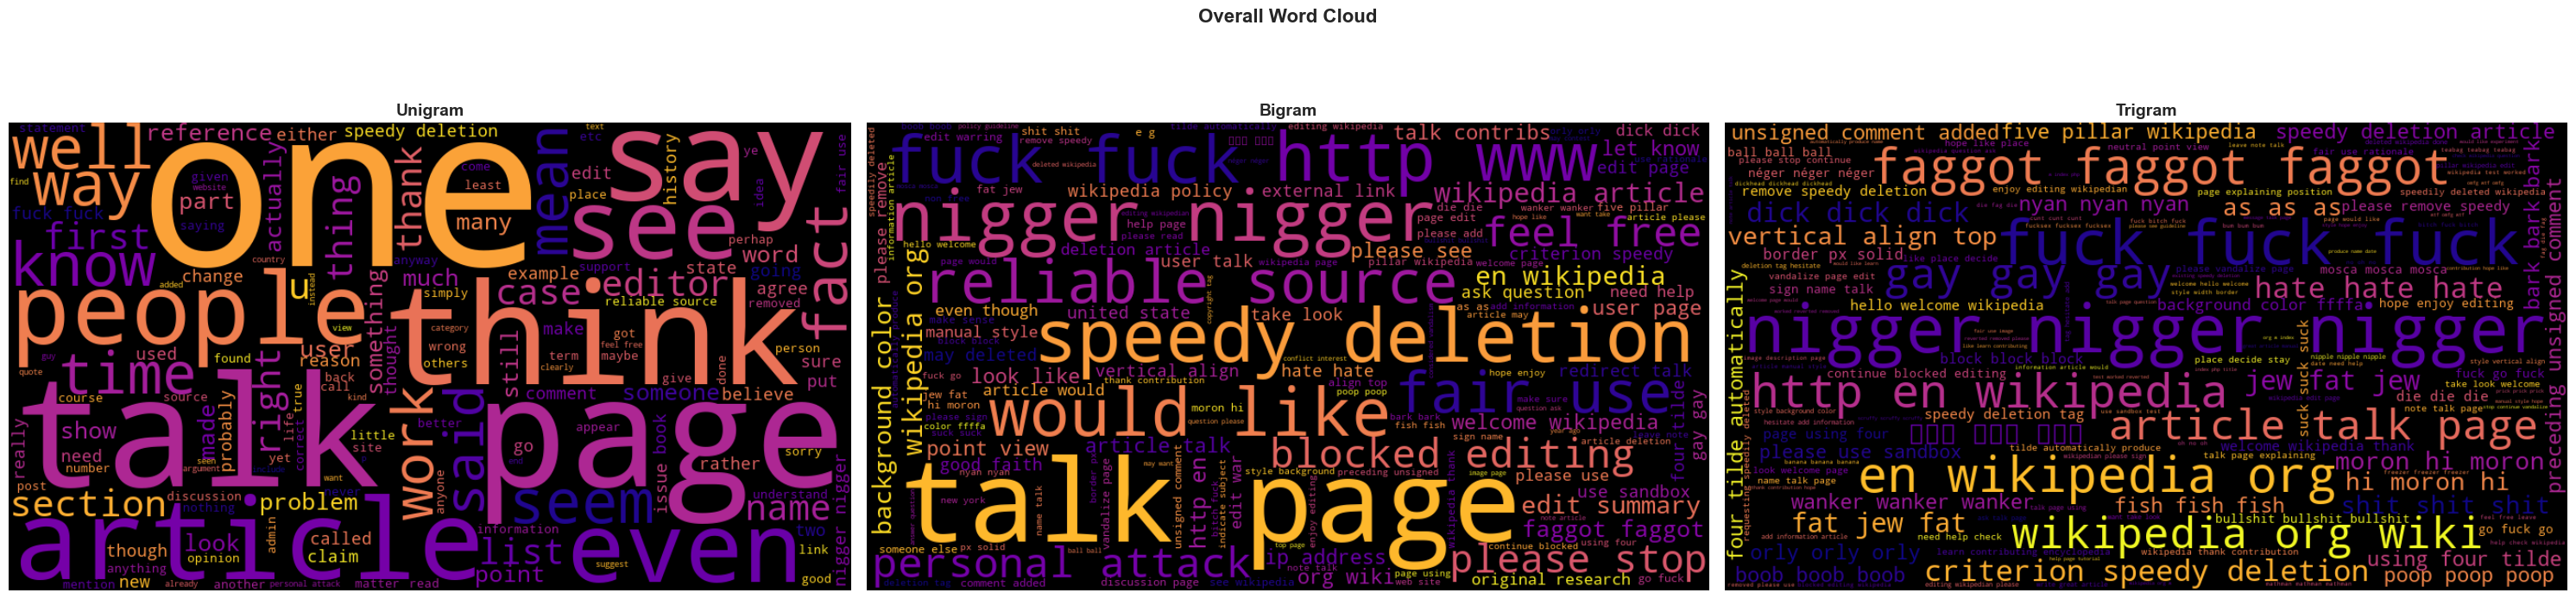

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))
fig.suptitle('Overall Word Cloud', fontsize=16, fontweight='bold')

ngram_configs = [
    (1, 'Unigram',  " ".join(train_df['comment_text'])),
    (2, 'Bigram', None),
    (3, 'Trigram', None),
]

for ax, (n, gram_name, raw_text) in zip(axes, ngram_configs):
    if n == 1:
        wc = WordCloud(width=900, height=500, background_color='black',
                       colormap='plasma', max_words=150).generate(raw_text)
    else:
        freq = get_ngram_freq(train_df['comment_text'].tolist(), n=n)
        wc = WordCloud(width=900, height=500, background_color='black',
                       colormap='plasma', max_words=150).generate_from_frequencies(freq)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(gram_name, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

4.2 Unigram on toxic comments

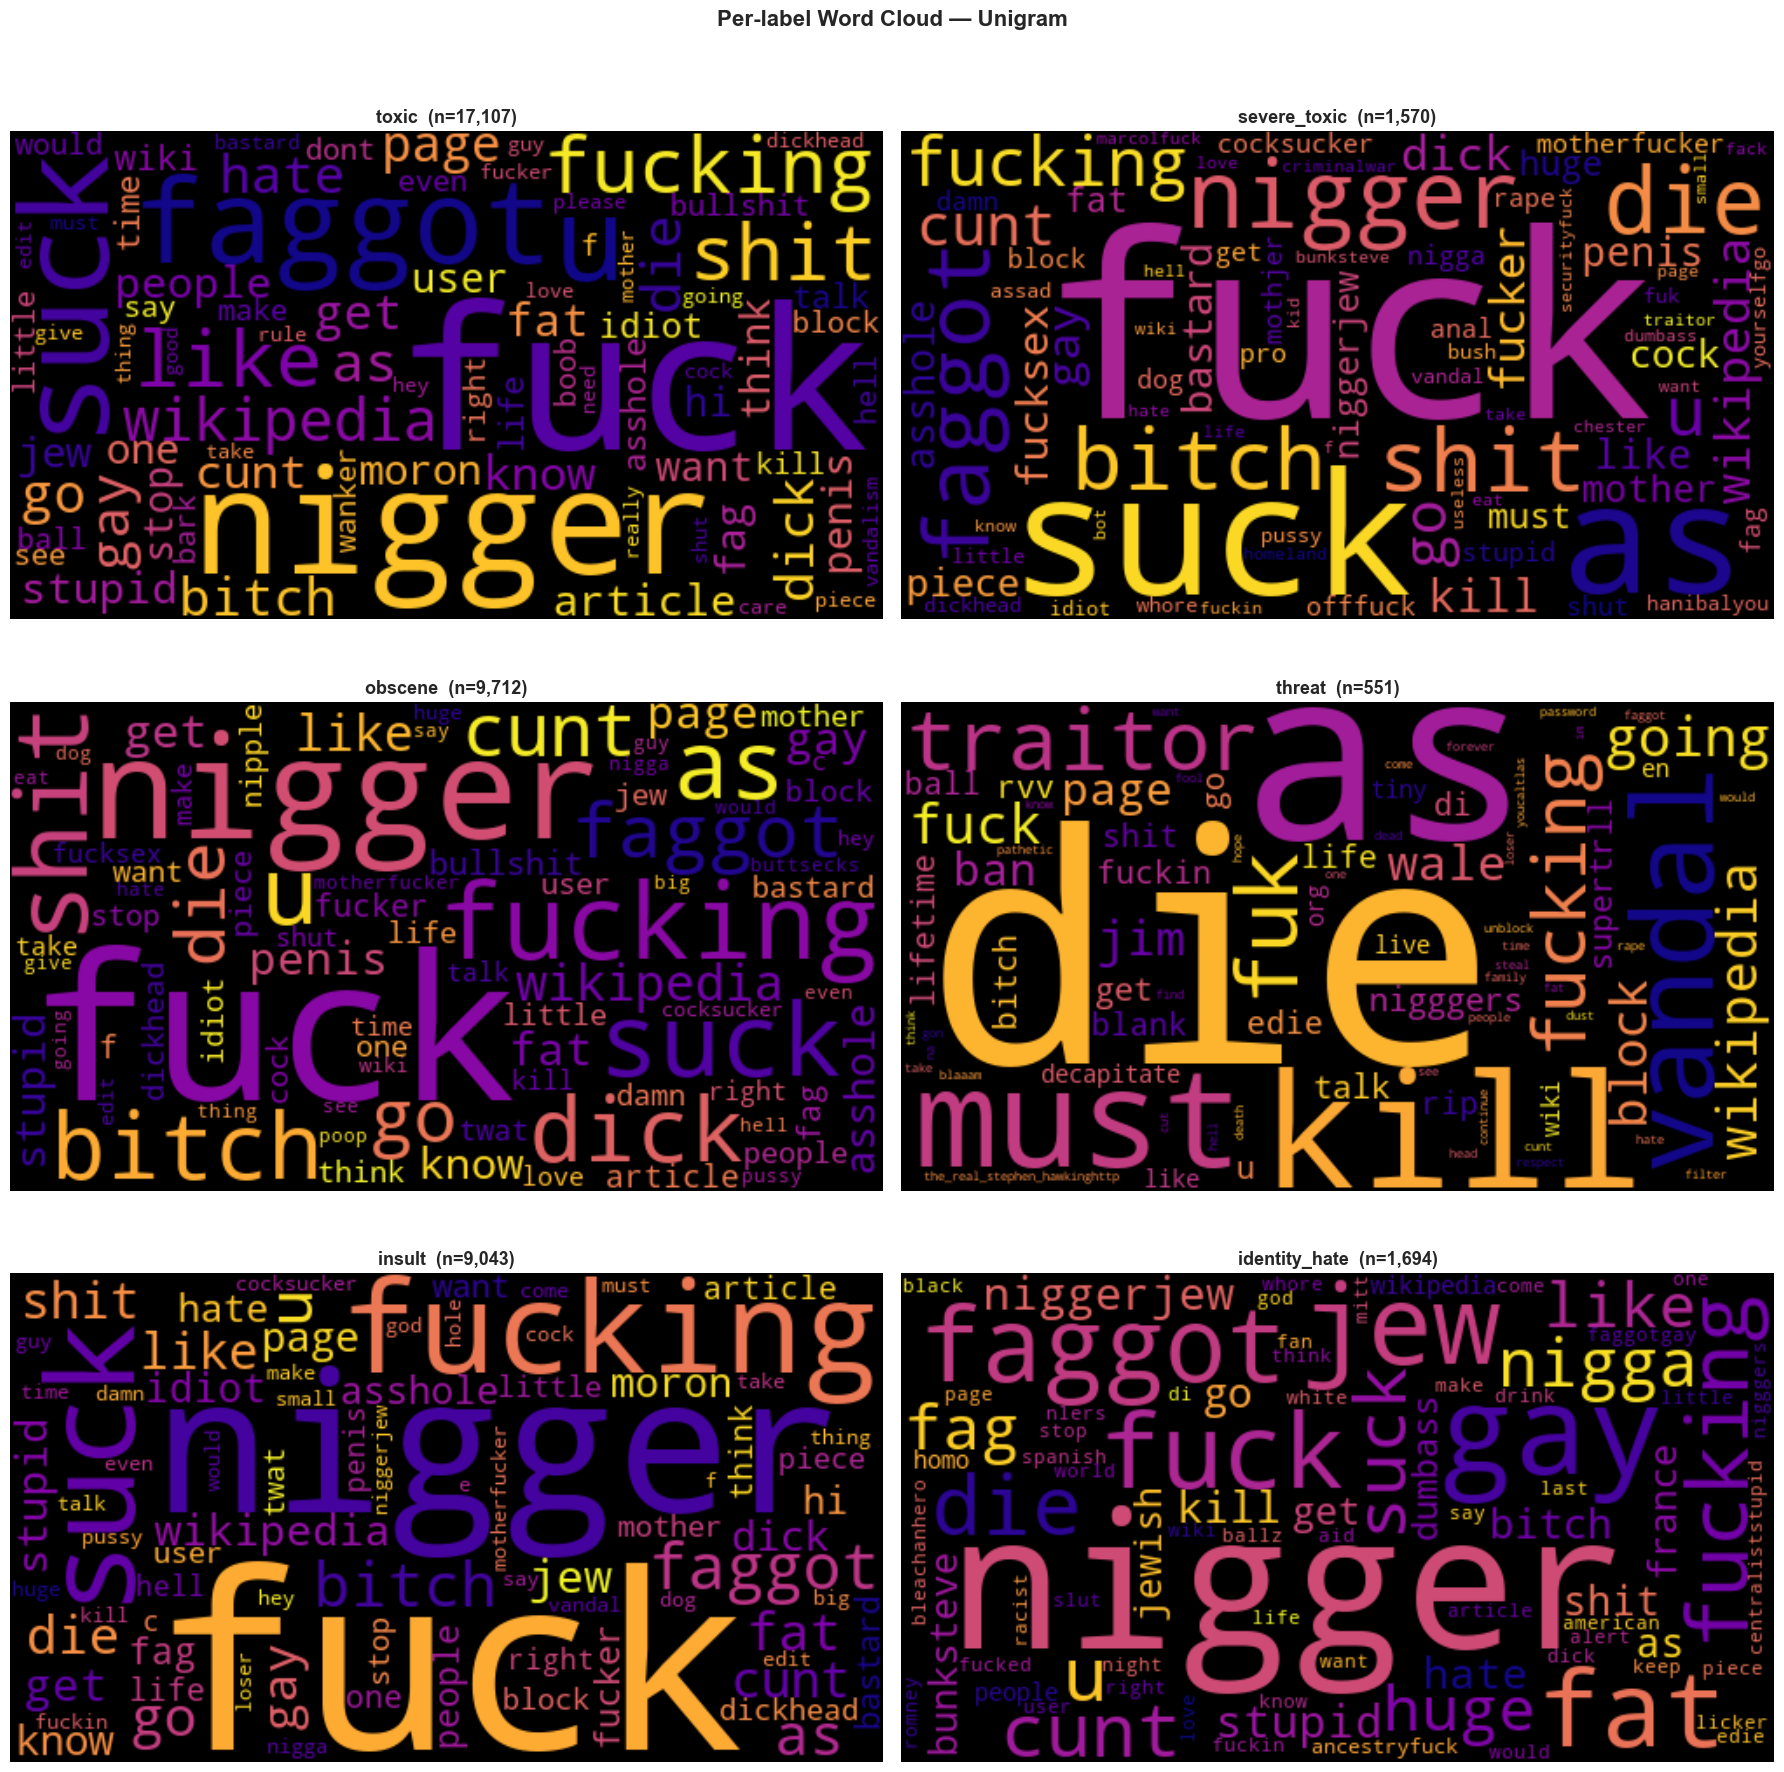

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Per-label Word Cloud — Unigram', fontsize=16, fontweight='bold', y=1.01)

for ax, label in zip(axes.flatten(), LABELS):
    label_texts = train_df.loc[train_df[label] == 1, 'comment_text'].tolist()
    freq = get_ngram_freq(label_texts, n=1)
    wc = WordCloud(**WC_KWARGS).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label}  (n={len(label_texts):,})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

4.3 Bigram on toxic comments

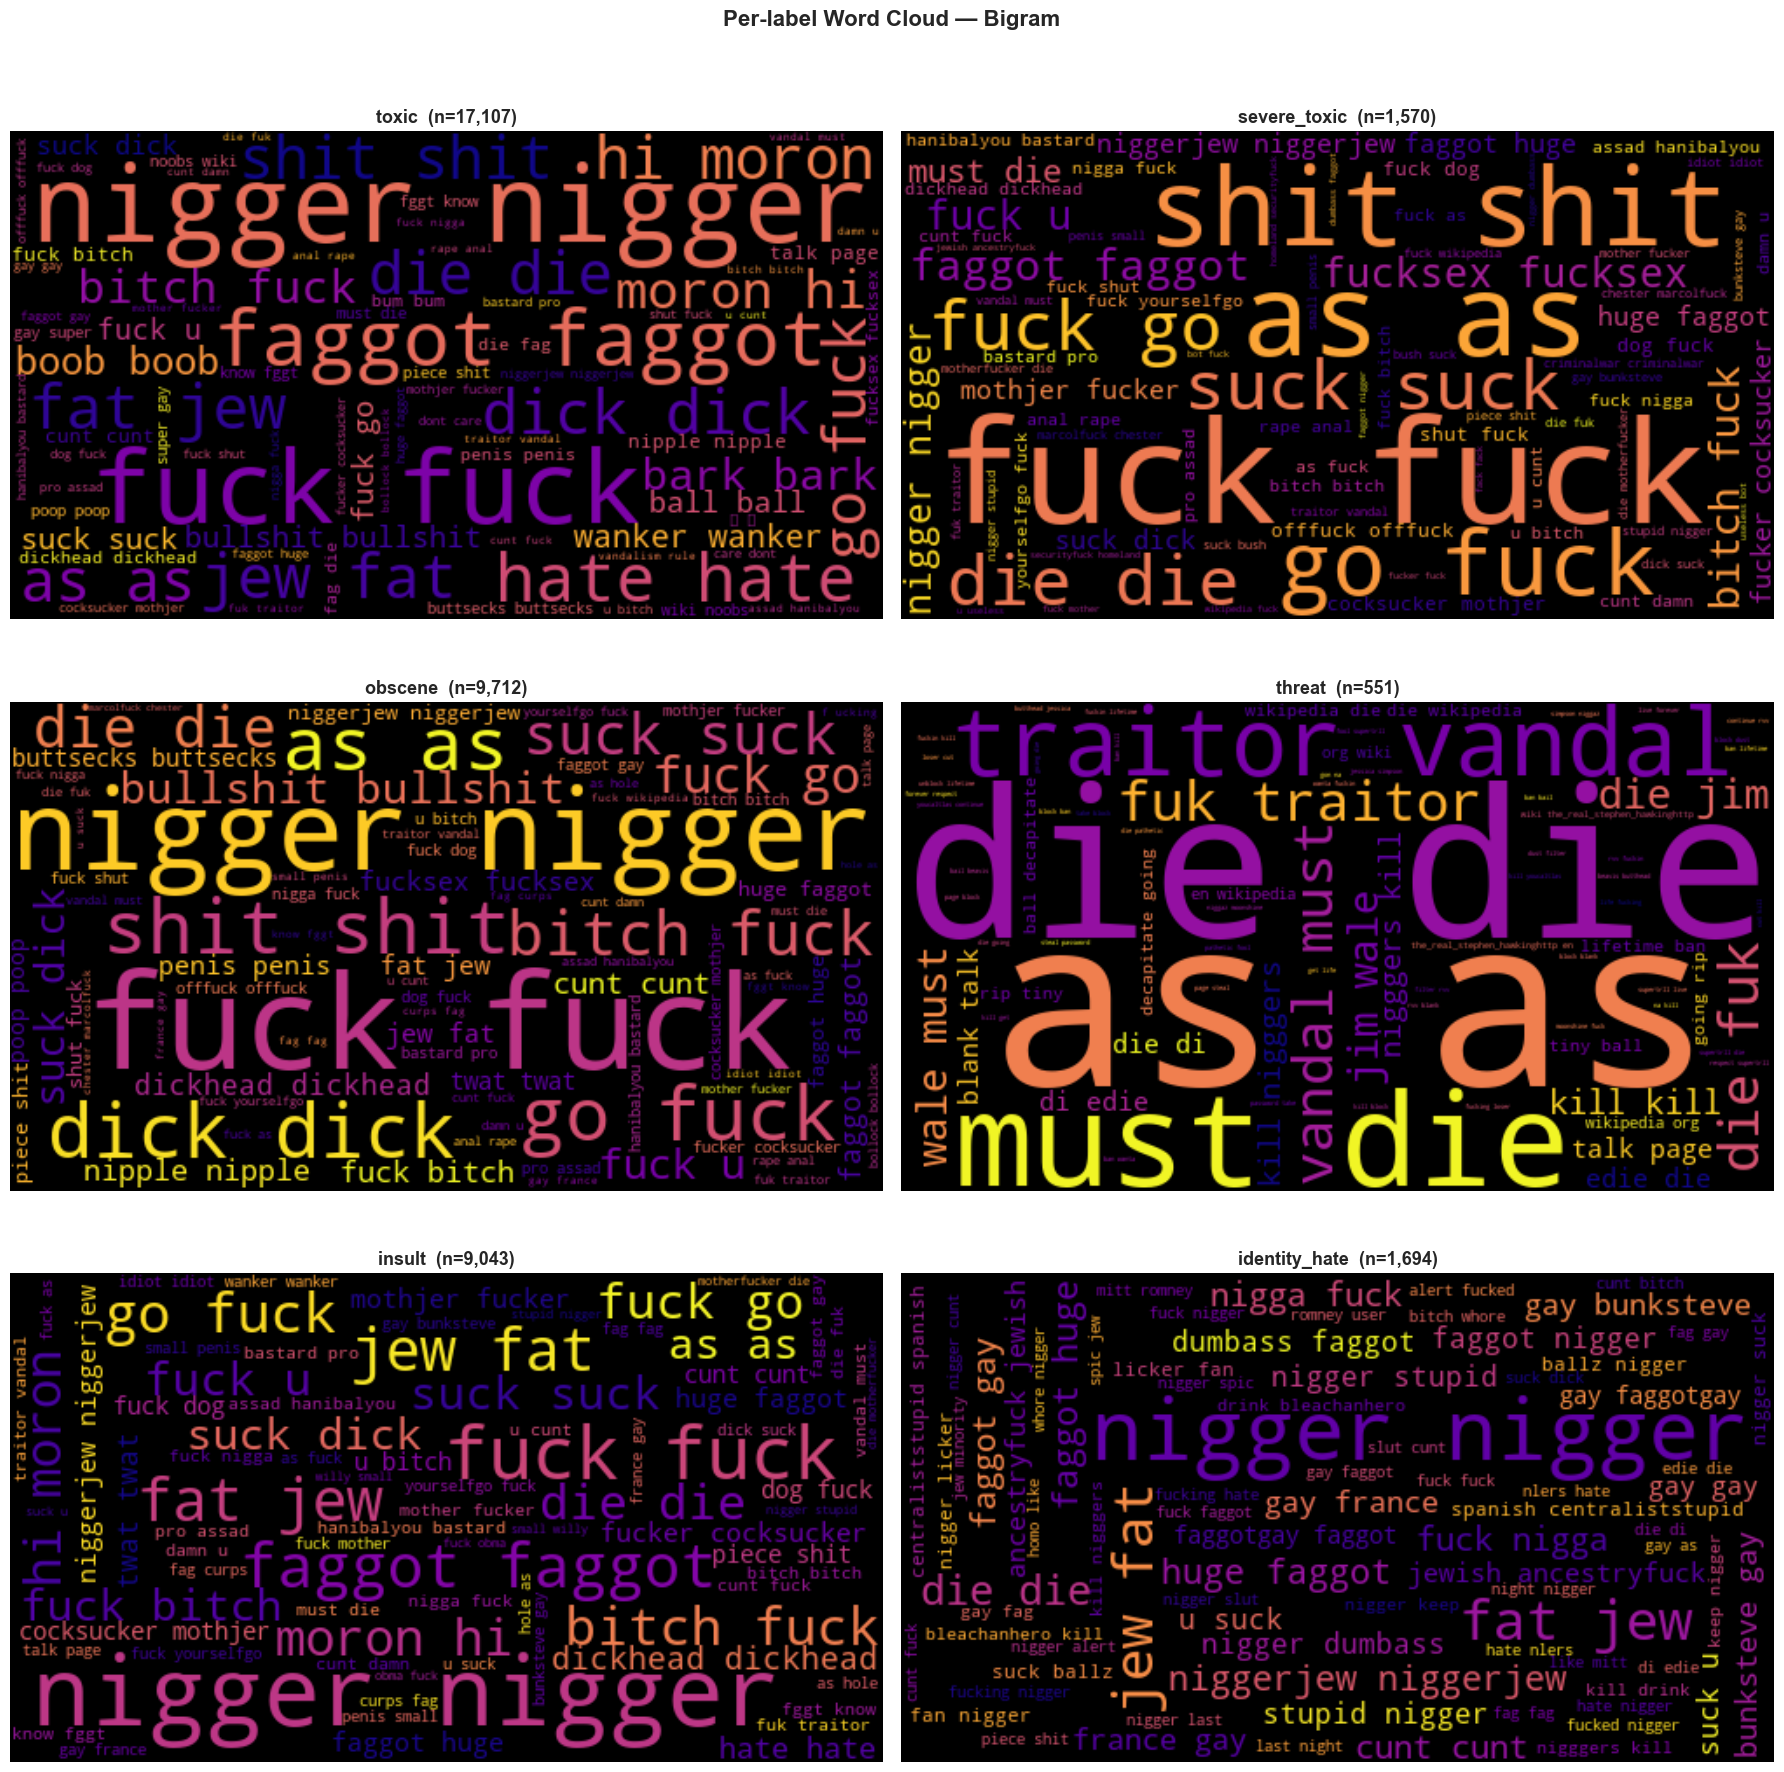

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Per-label Word Cloud — Bigram', fontsize=16, fontweight='bold', y=1.01)

for ax, label in zip(axes.flatten(), LABELS):
    label_texts = train_df.loc[train_df[label] == 1, 'comment_text'].tolist()
    freq = get_ngram_freq(label_texts, n=2)
    wc = WordCloud(**WC_KWARGS).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label}  (n={len(label_texts):,})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

4.4 Trigram on toxic comments

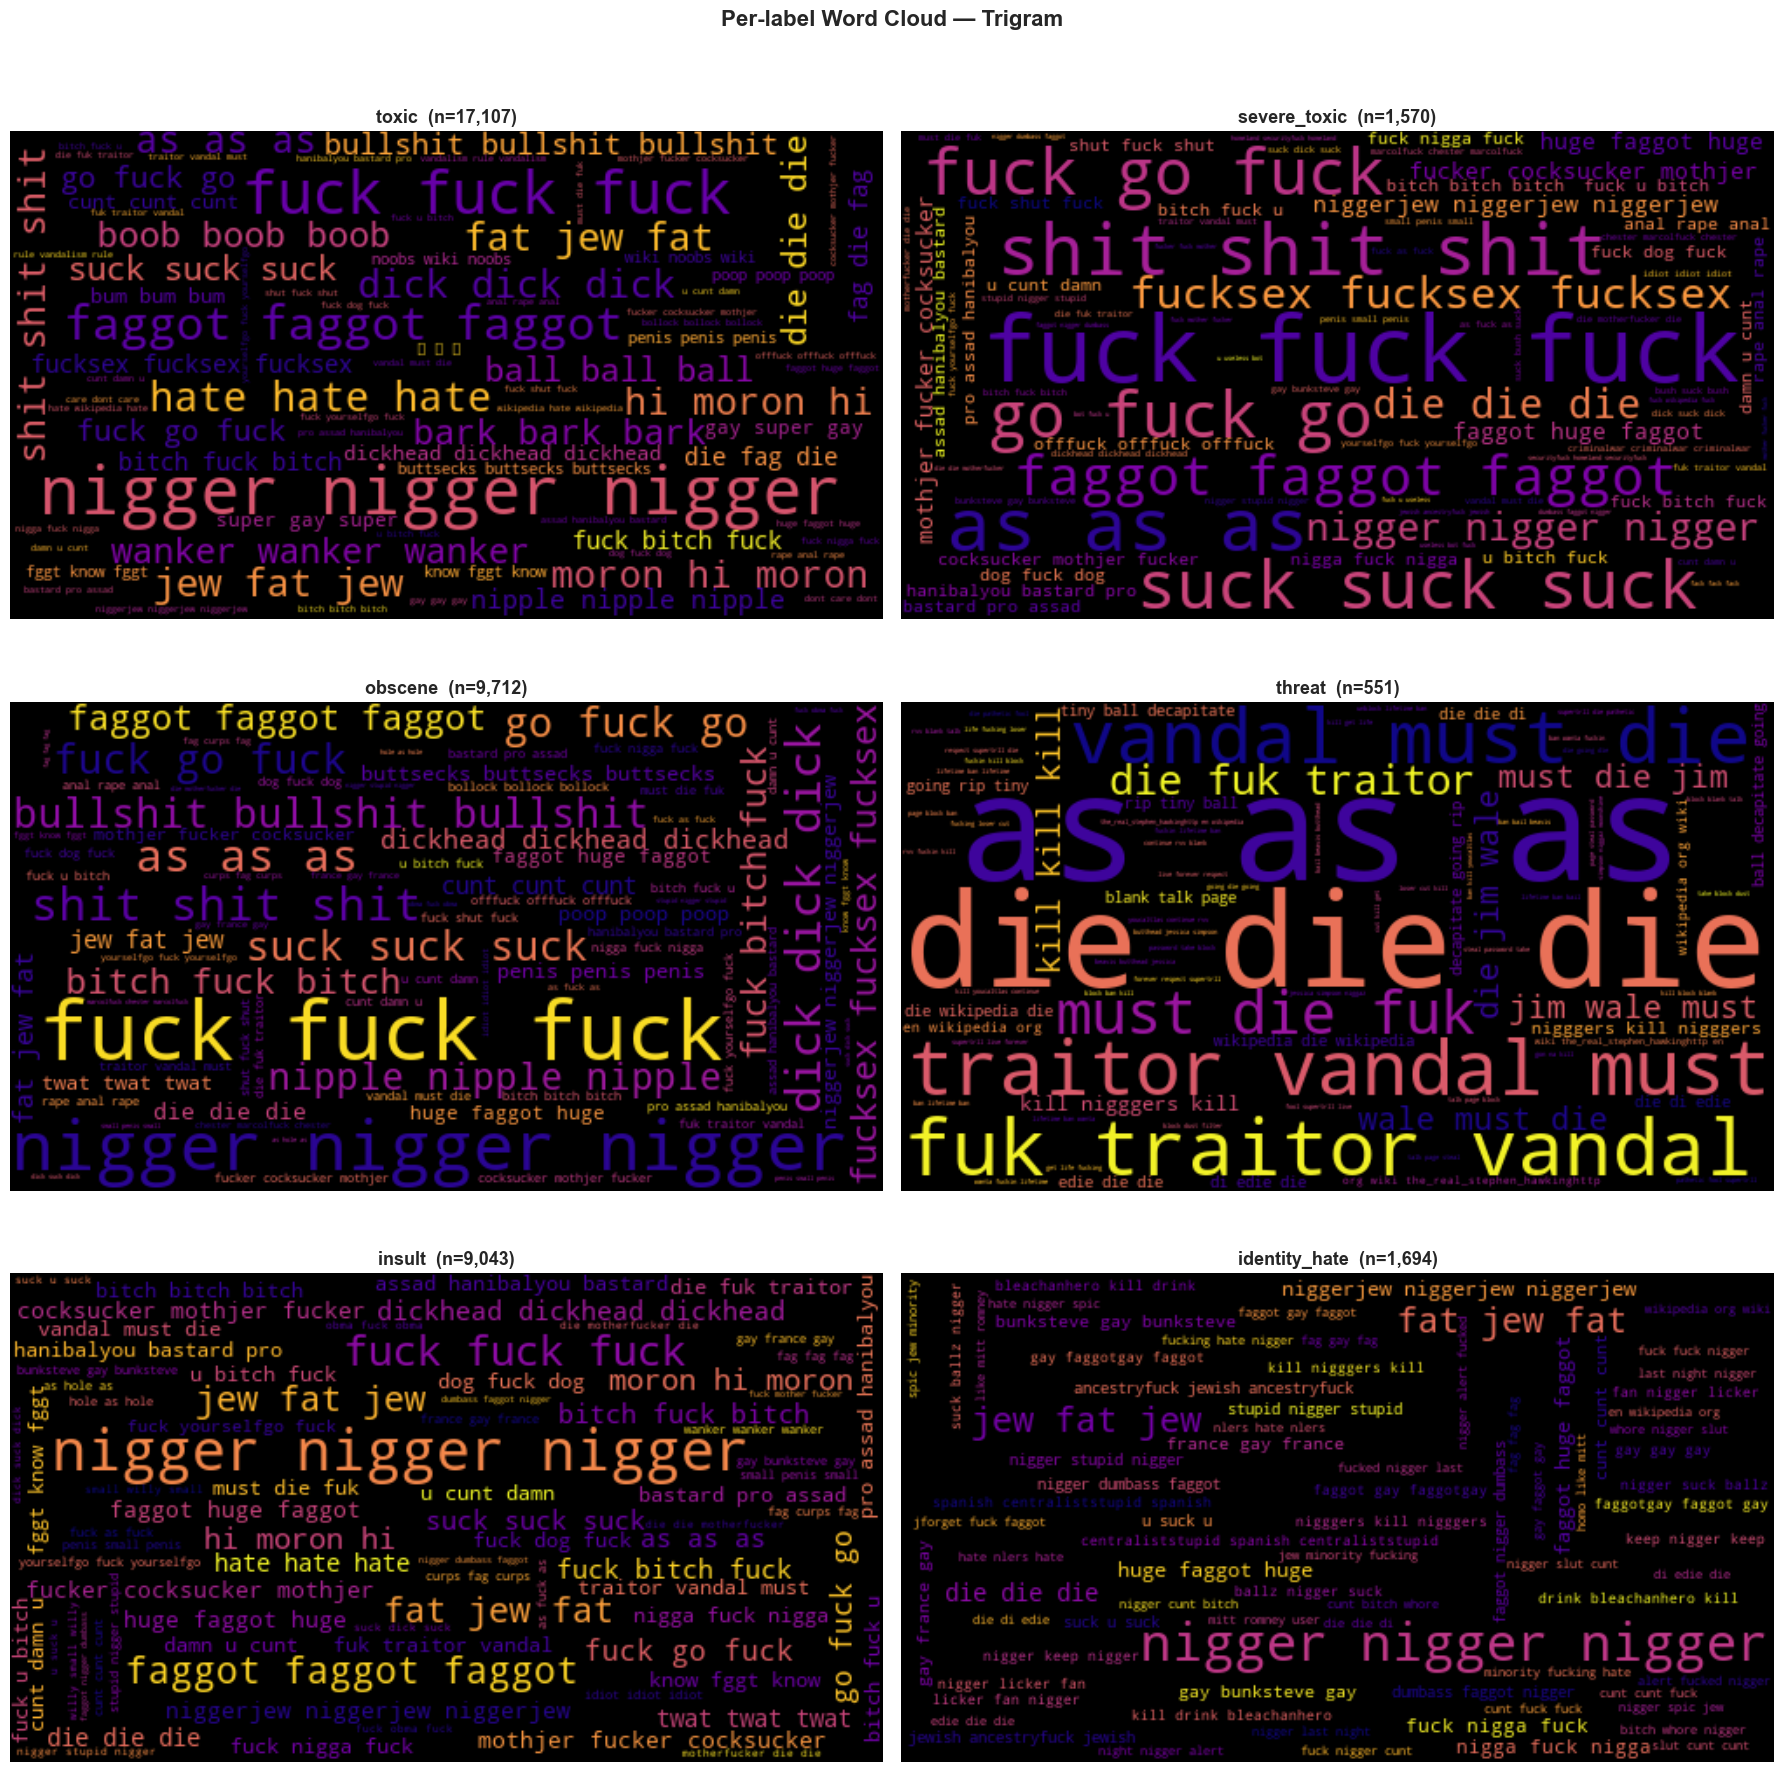

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Per-label Word Cloud — Trigram', fontsize=16, fontweight='bold', y=1.01)

for ax, label in zip(axes.flatten(), LABELS):
    label_texts = train_df.loc[train_df[label] == 1, 'comment_text'].tolist()
    freq = get_ngram_freq(label_texts, n=3)
    wc = WordCloud(**WC_KWARGS).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label}  (n={len(label_texts):,})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**5. High-frequency Words for Each Label**

5.1 High-frequency Words per Label (Top-15 Bar Charts)

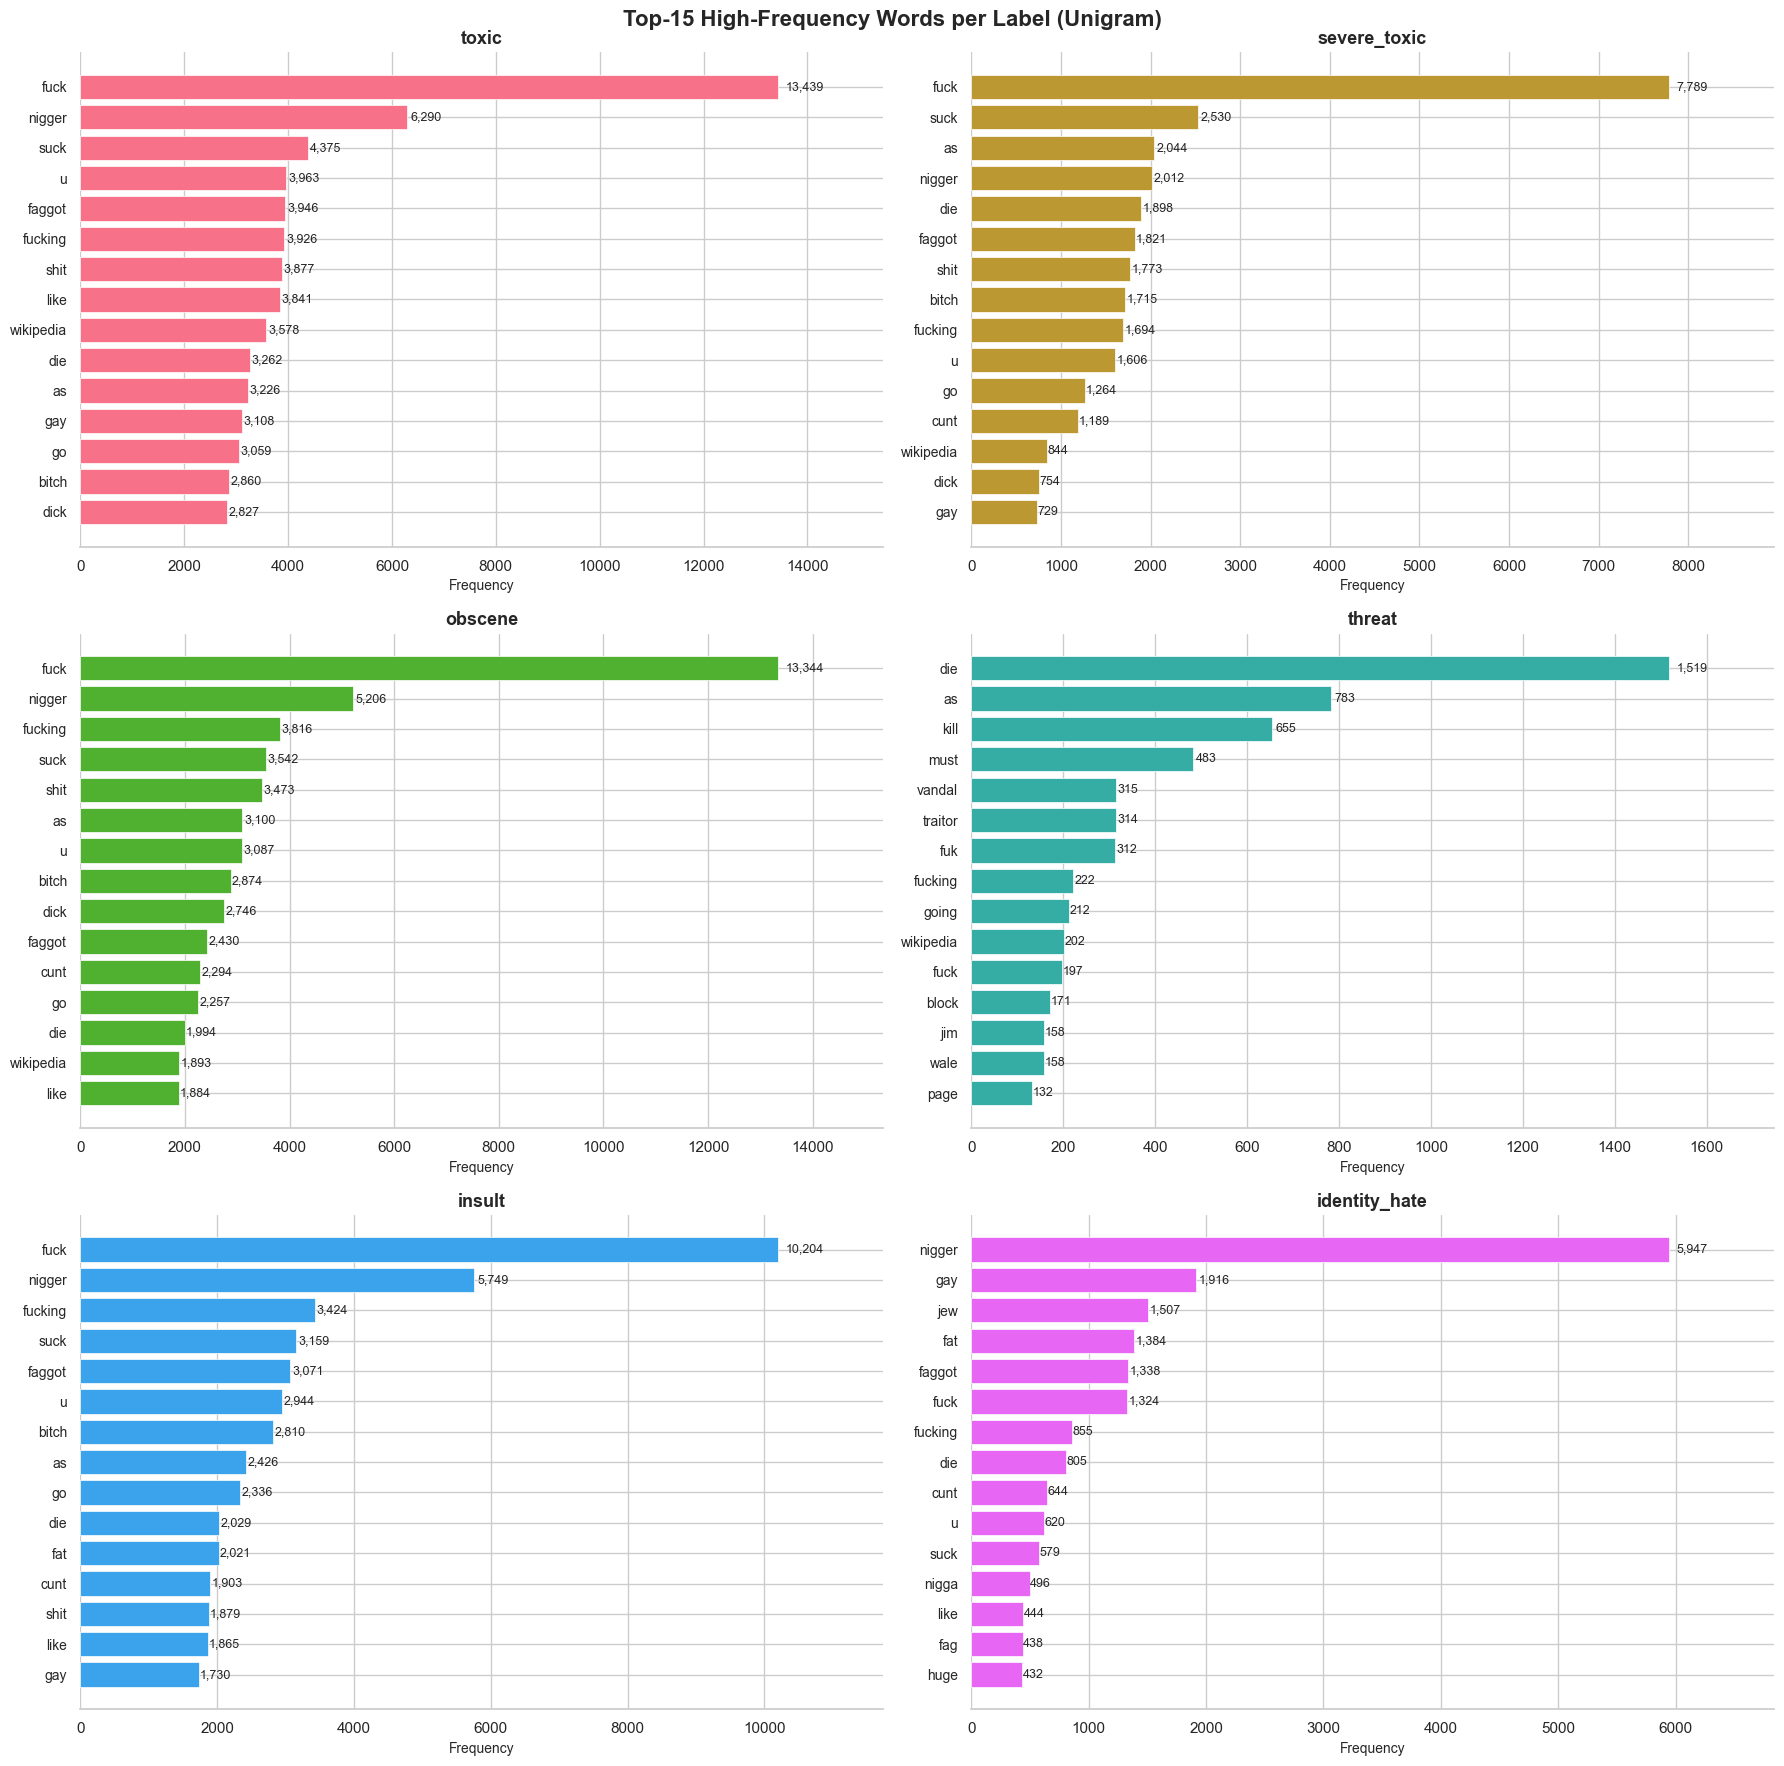

In [13]:
TOP_N = 15

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle(f'Top-{TOP_N} High-Frequency Words per Label (Unigram)', fontsize=16, fontweight='bold')

for ax, label, color in zip(axes.flatten(), LABELS, LABEL_COLORS):
    label_texts = train_df.loc[train_df[label] == 1, 'comment_text'].tolist()
    freq = get_ngram_freq(label_texts, n=1)
    top_words = pd.DataFrame(freq.most_common(TOP_N), columns=['word', 'count'])

    ax.barh(top_words['word'][::-1], top_words['count'][::-1],
            color=color, edgecolor='white', linewidth=0.5)
    for bar, val in zip(ax.patches, top_words['count'][::-1]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=9)

    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency', fontsize=10)
    ax.set_xlim(0, top_words['count'].max() * 1.15)
    ax.tick_params(axis='y', labelsize=10)
    sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
plt.show()

5.2 Top Bigrams per Label

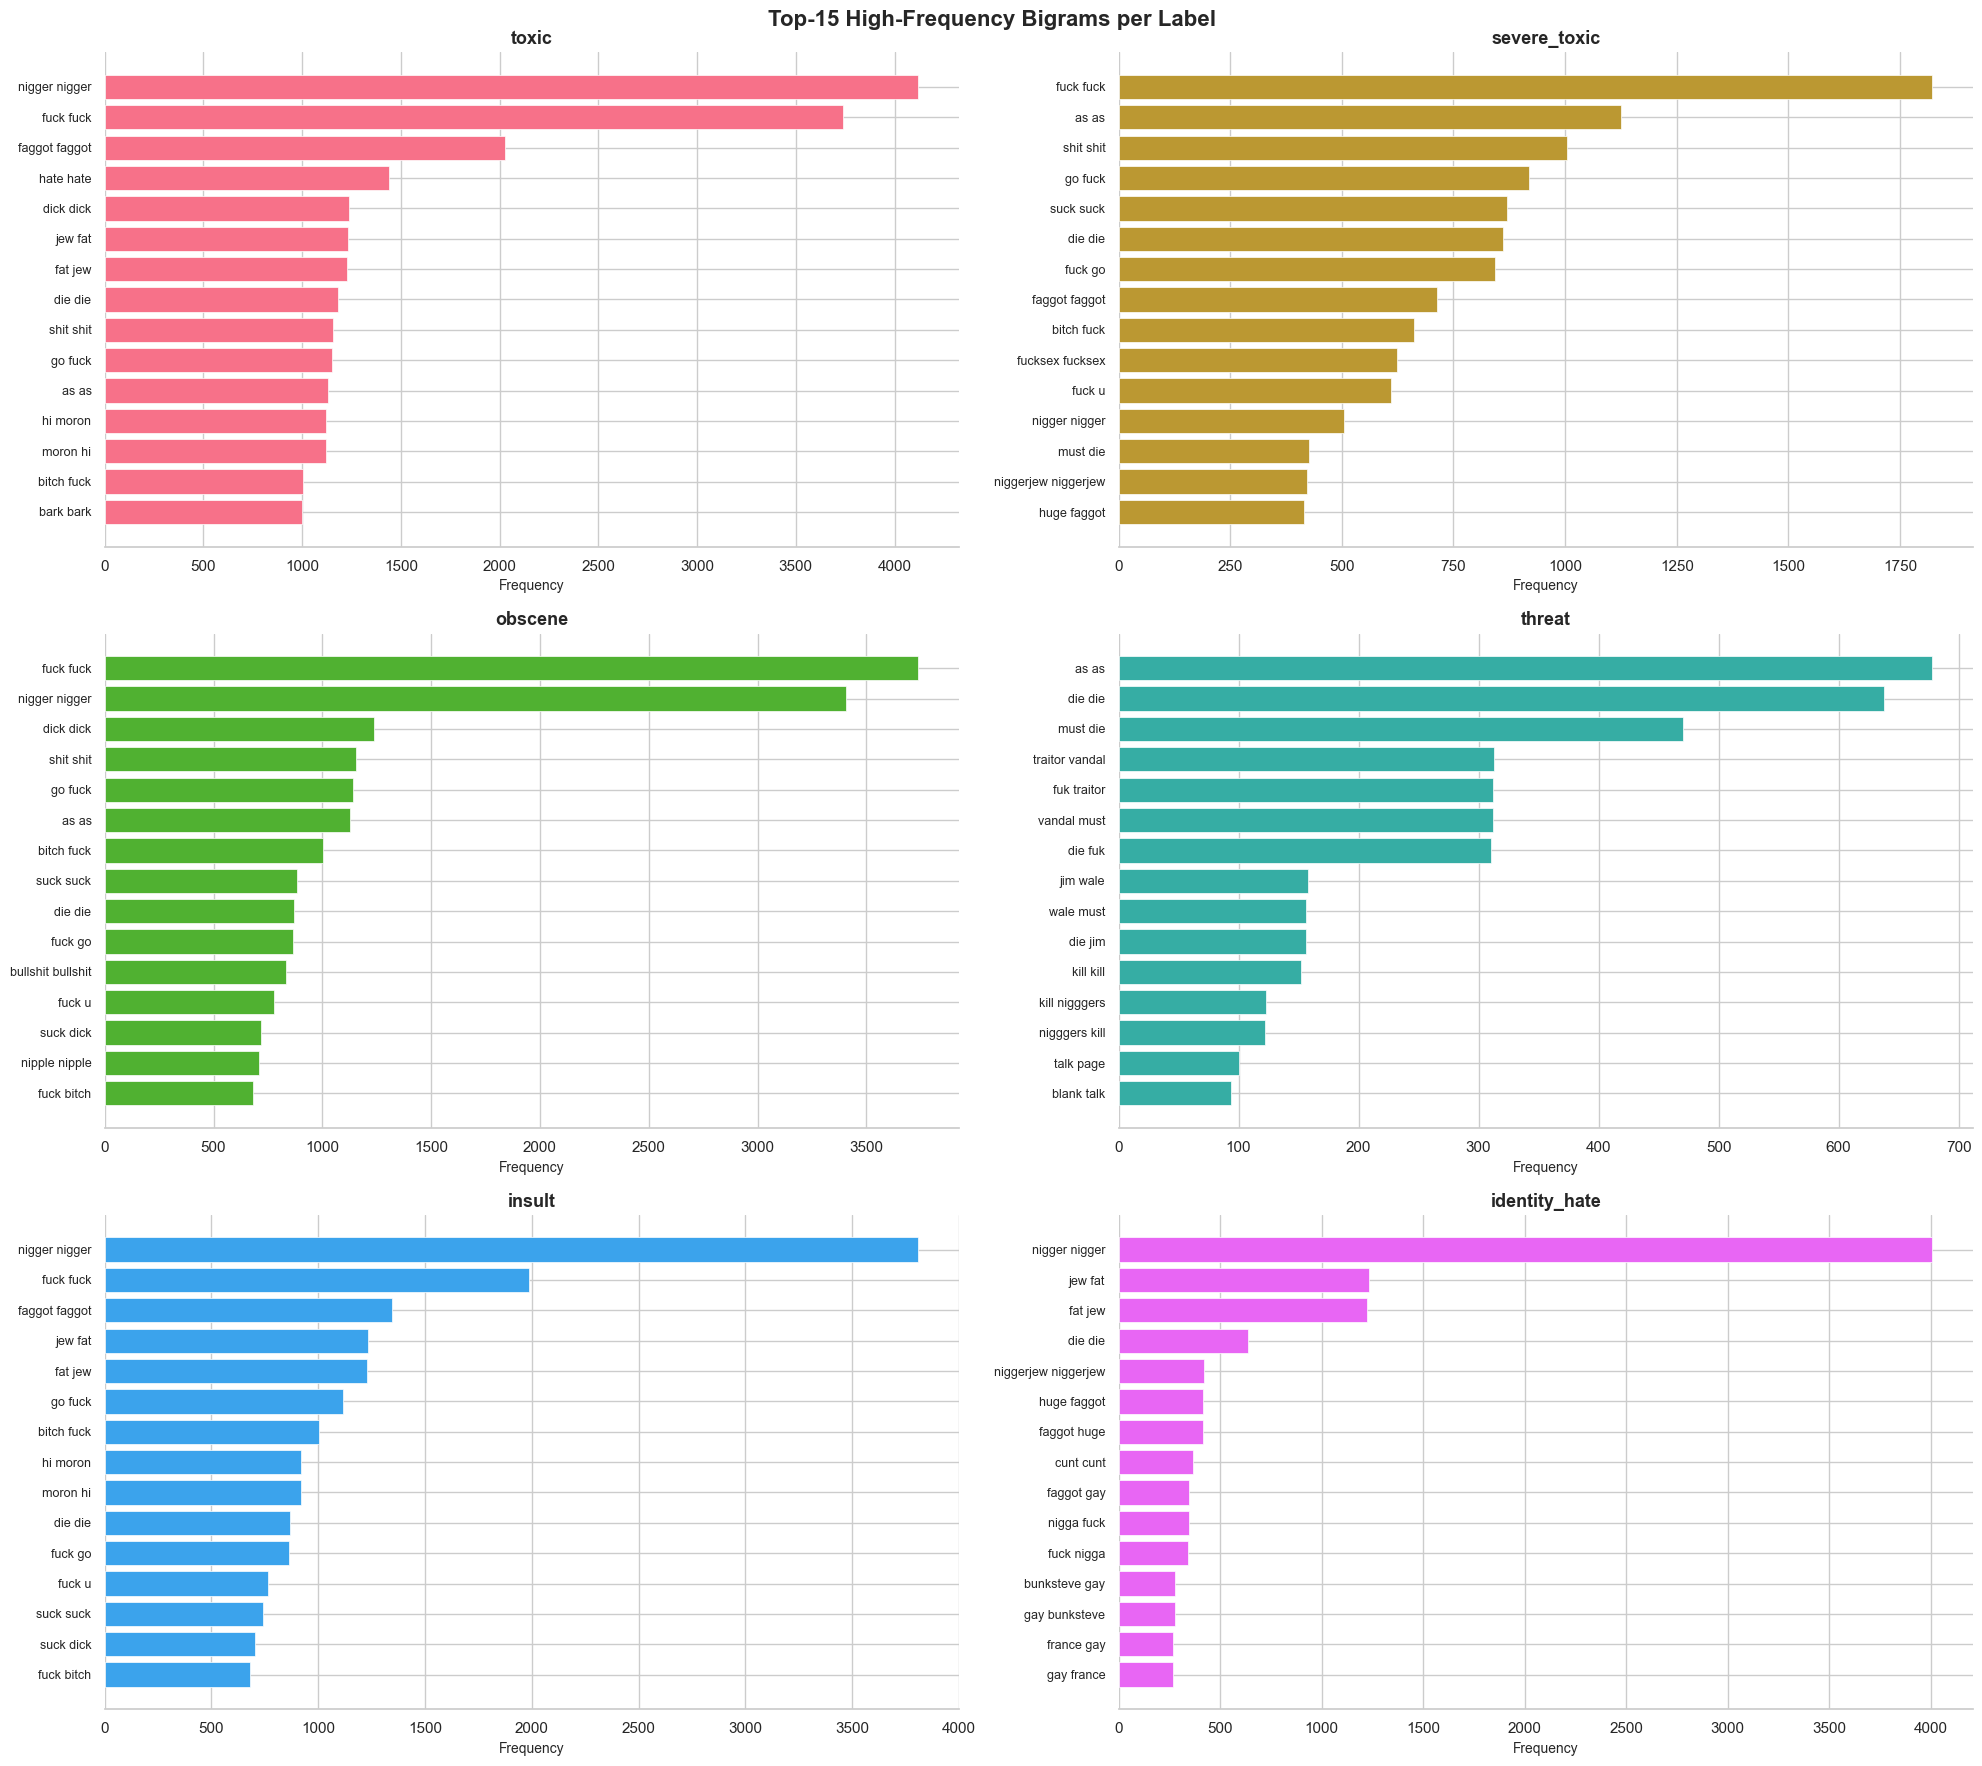

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle(f'Top-{TOP_N} High-Frequency Bigrams per Label', fontsize=16, fontweight='bold')

for ax, label, color in zip(axes.flatten(), LABELS, LABEL_COLORS):
    label_texts = train_df.loc[train_df[label] == 1, 'comment_text'].tolist()
    freq = get_ngram_freq(label_texts, n=2)
    top_bigrams = pd.DataFrame(freq.most_common(TOP_N), columns=['bigram', 'count'])

    ax.barh(top_bigrams['bigram'][::-1], top_bigrams['count'][::-1],
            color=color, edgecolor='white', linewidth=0.5)

    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
plt.show()

5.3 Top Trigrams per Label

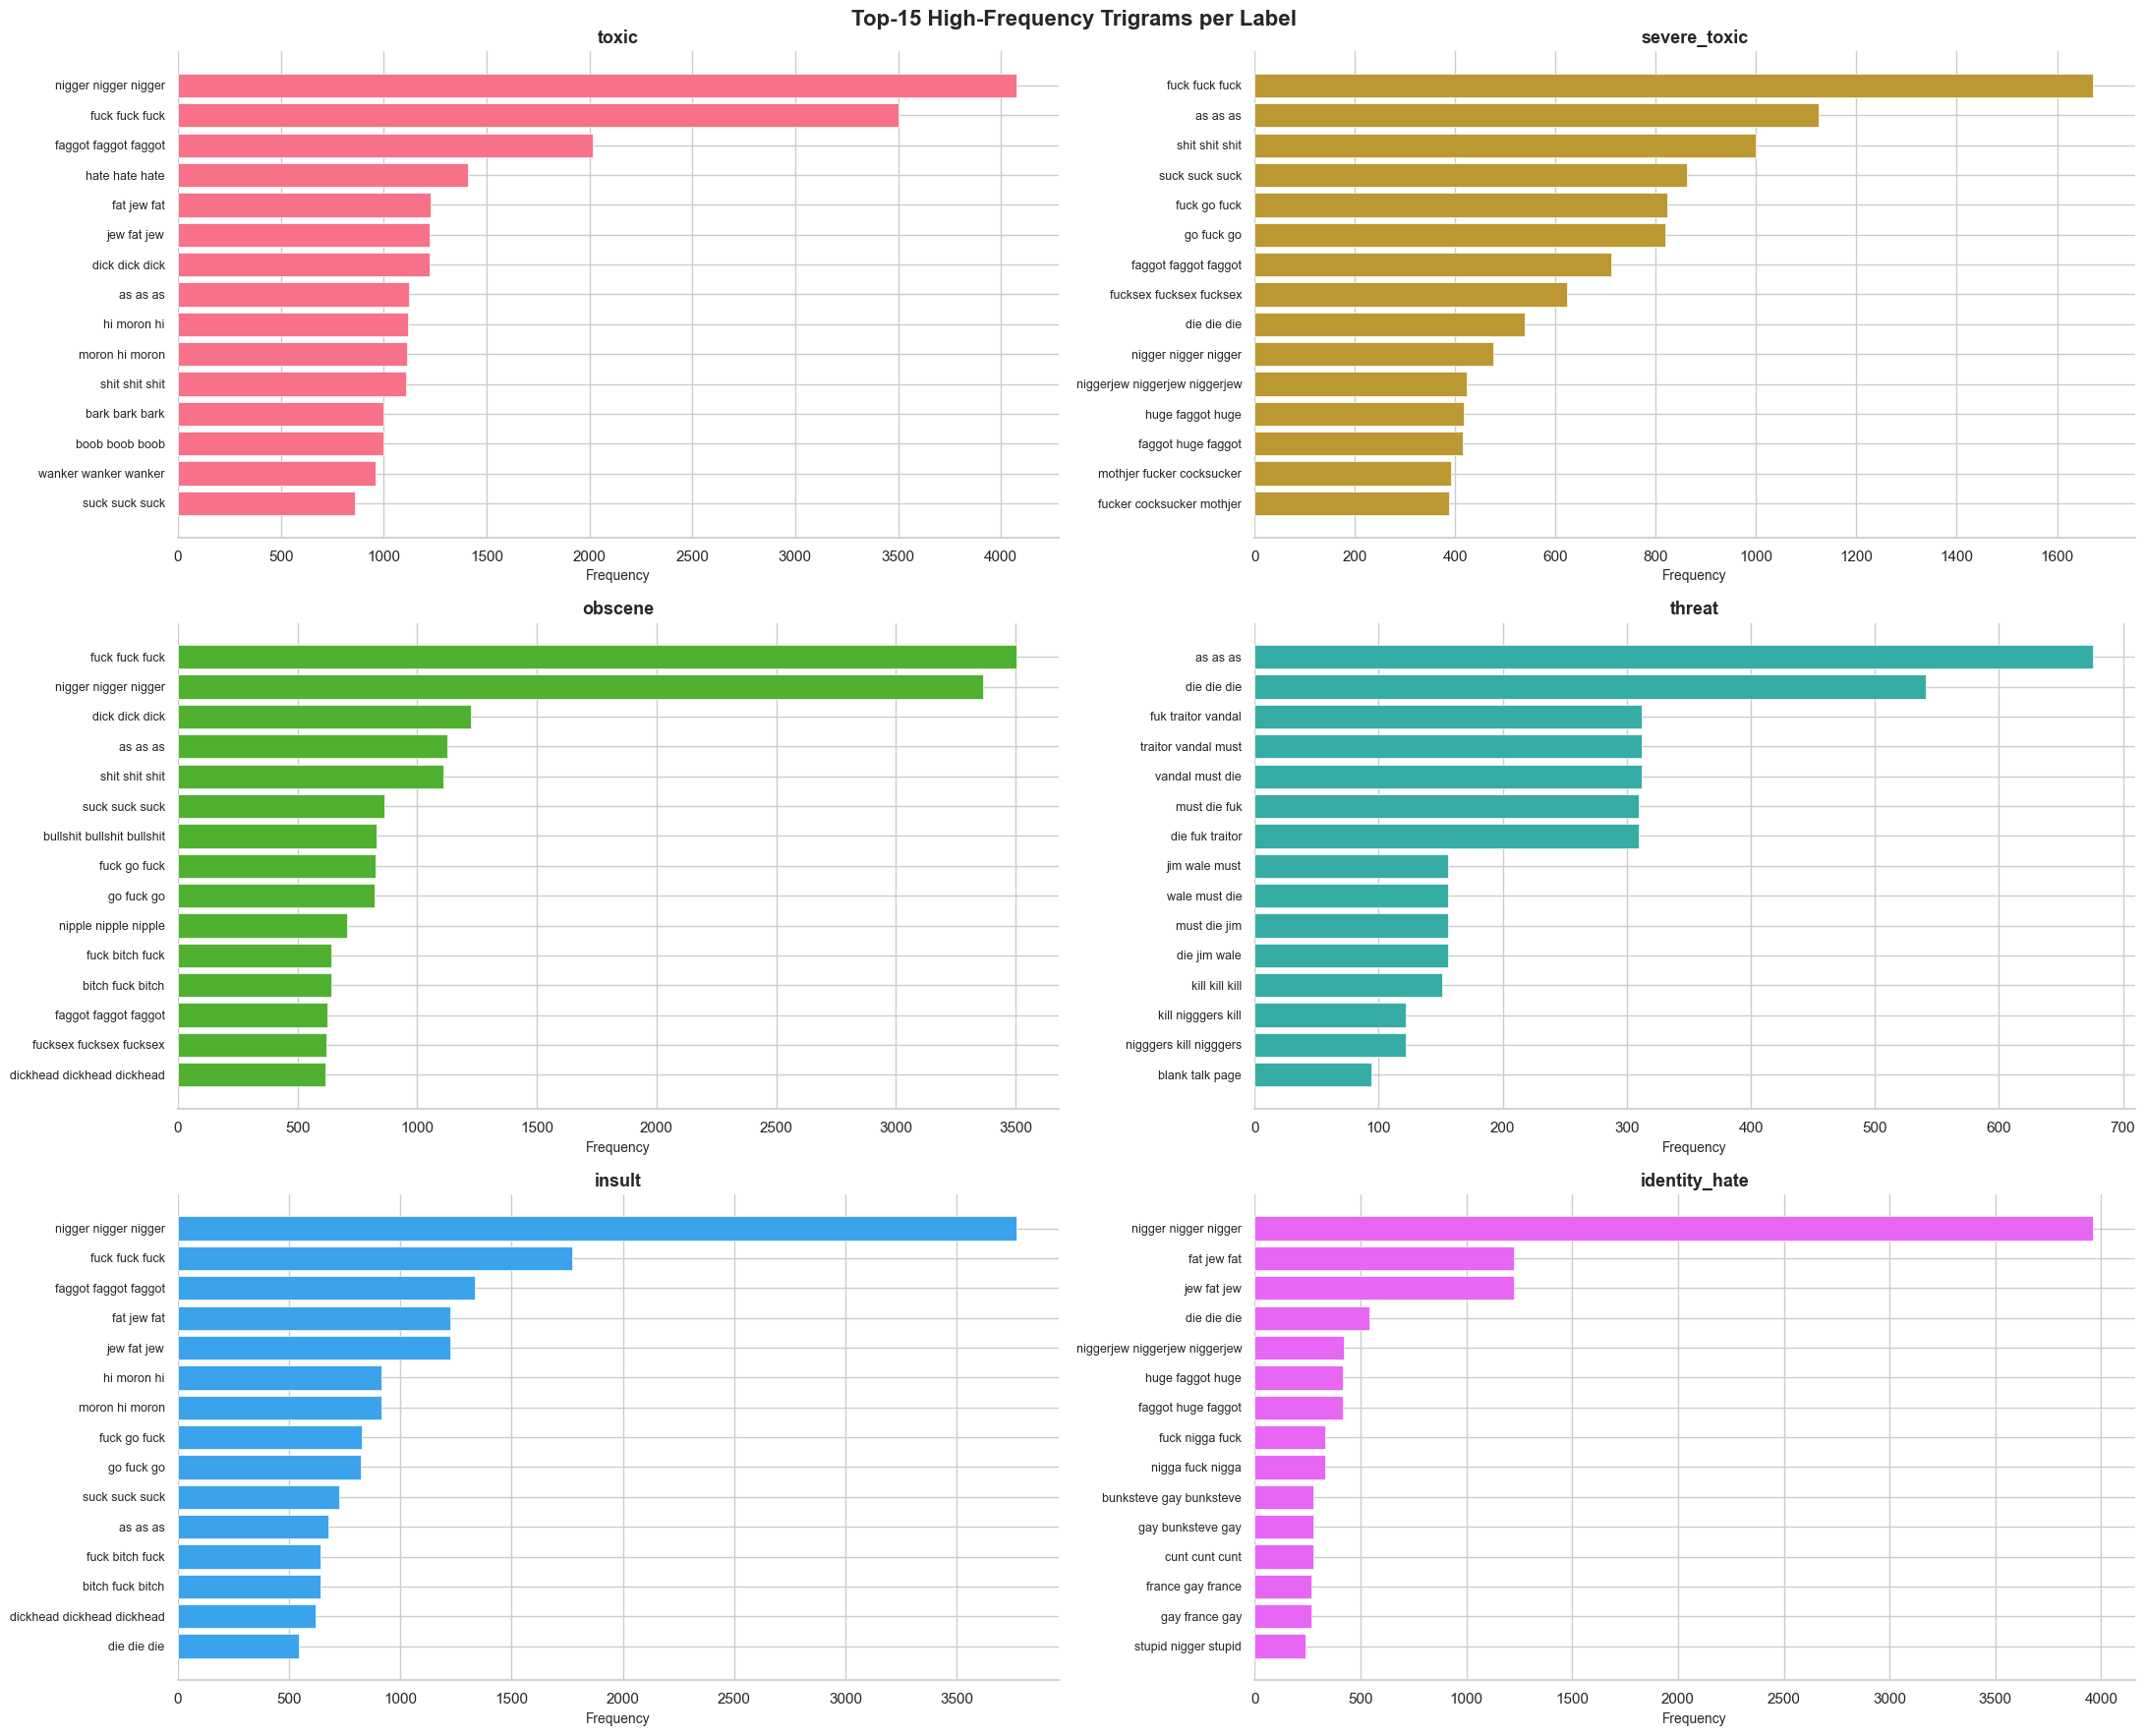

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(22, 18))
fig.suptitle(f'Top-{TOP_N} High-Frequency Trigrams per Label', fontsize=16, fontweight='bold')

for ax, label, color in zip(axes.flatten(), LABELS, LABEL_COLORS):
    label_texts = train_df.loc[train_df[label] == 1, 'comment_text'].tolist()
    freq = get_ngram_freq(label_texts, n=3)
    top_trigrams = pd.DataFrame(freq.most_common(TOP_N), columns=['trigram', 'count'])

    ax.barh(top_trigrams['trigram'][::-1], top_trigrams['count'][::-1],
            color=color, edgecolor='white', linewidth=0.5)

    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
plt.show()

**6. Per-label Length Distribution**

In [16]:
# compute word length of each comment
train_df['comment_length'] = train_df['comment_text'].apply(lambda x: len(x.split()))

labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

length_data = []

for label in labels:
    subset = train_df[train_df[label] == 1]['comment_length']

    for length in subset:
        length_data.append([label, length])

length_df = pd.DataFrame(length_data, columns=['label','comment_length'])

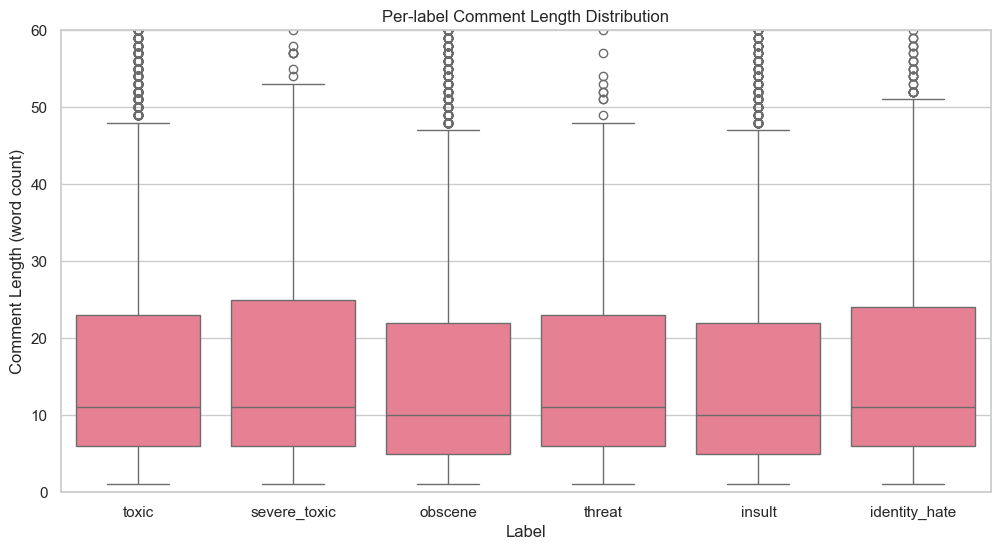

In [17]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=length_df,
    x='label',
    y='comment_length'
)

plt.ylim(0,60)

plt.title("Per-label Comment Length Distribution")
plt.xlabel("Label")
plt.ylabel("Comment Length (word count)")

plt.show()

In [18]:
length_df.groupby('label')['comment_length'].median()

label
identity_hate    11.0
insult           10.0
obscene          10.0
severe_toxic     11.0
threat           11.0
toxic            11.0
Name: comment_length, dtype: float64

The distribution of comment lengths across different toxicity labels appears relatively similar. Most comments contain fewer than 50 words, while a small number of extreme outliers exceed several hundred words. These long comments are rare and are unlikely to significantly influence model performance. Therefore, sequence length truncation will be applied during model training.

**7. Toxic vs Non-Toxic Length Boxplot**

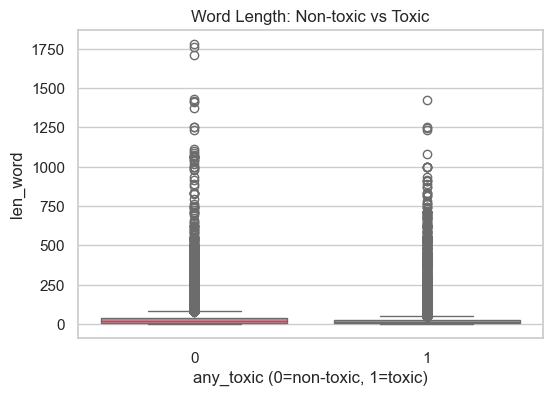

In [19]:
# make sure comment_text exists and is string
train_df["comment_text"] = train_df["comment_text"].fillna("").astype(str)

# create length features
train_df["len_char"] = train_df["comment_text"].str.len()
train_df["len_word"] = train_df["comment_text"].str.split().apply(len)

train_df["any_toxic"] = (train_df[LABELS].sum(axis=1) > 0).astype(int)

plt.figure(figsize=(6, 4))
sns.boxplot(x="any_toxic", y="len_word", data=train_df)
plt.title("Word Length: Non-toxic vs Toxic")
plt.xlabel("any_toxic (0=non-toxic, 1=toxic)")
plt.ylabel("len_word")
plt.show()

**8. Baseline Difficulty Preview via Logistic Regression**

In [20]:
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

# split data
X_train, X_val, y_train, y_val = train_test_split(
    train_df['comment_text'],
    train_df[labels],
    test_size=0.2,
    random_state=49458345
)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

# Logistic Regression (multi-label)
model = OneVsRestClassifier(LogisticRegression(max_iter=200))
model.fit(X_train_tfidf, y_train)

# prediction
y_pred_prob = model.predict_proba(X_val_tfidf)
y_pred = model.predict(X_val_tfidf)

# evaluation
for i, label in enumerate(labels):
    auc = roc_auc_score(y_val[label], y_pred_prob[:, i])
    f1 = f1_score(y_val[label], y_pred[:, i])
    f2 = fbeta_score(y_val[label], y_pred[:, i], beta=2)
    rec = recall_score(y_val[label], y_pred[:, i])
    print(f"{label:15} ROC-AUC: {auc:.4f}   F1: {f1:.4f}   F2: {f2:.4f}   Recall: {rec:.4f}")

toxic           ROC-AUC: 0.9659   F1: 0.6998   F2: 0.6263   Recall: 0.5854
severe_toxic    ROC-AUC: 0.9866   F1: 0.3121   F2: 0.2547   Recall: 0.2268
obscene         ROC-AUC: 0.9828   F1: 0.7336   F2: 0.6651   Recall: 0.6261
threat          ROC-AUC: 0.9849   F1: 0.1667   F2: 0.1166   Recall: 0.0971
insult          ROC-AUC: 0.9774   F1: 0.6373   F2: 0.5661   Recall: 0.5268
identity_hate   ROC-AUC: 0.9785   F1: 0.3753   F2: 0.2910   Recall: 0.2531


The high ROC-AUC scores obtained by the logistic regression baseline indicate that many toxicity categories are strongly associated with specific lexical patterns.   
However, the model performs significantly worse on rare classes such as threat and identity_hate. This is likely due to extreme class imbalance. The discrepancy between ROC-AUC and F1 suggests that probability ranking is good, but the default decision threshold is not optimal for rare classes.